In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

In [5]:
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

In [2]:
from sklearn.datasets import make_classification
X, Y = make_classification(n_samples=1000, n_classes=2, n_features=5, n_redundant=0, random_state=1)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4)    
X_test, X_val, Y_test, Y_val = train_test_split(X_test, Y_test, test_size=0.5)

In [17]:
names = ["Nearest_Neighbors", "Linear_SVM", "Polynomial_SVM", "RBF_SVM", "Gaussian_Process",
         "Gradient_Boosting", "Decision_Tree", "Extra_Trees", "Random_Forest", "Neural_Net", "AdaBoost",
         "Naive_Bayes", "QDA", "SGD"]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(kernel="poly", degree=3, C=0.025),
    SVC(kernel="rbf", C=1, gamma=2),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0),
    DecisionTreeClassifier(max_depth=5),
    ExtraTreesClassifier(n_estimators=10, min_samples_split=2),
    RandomForestClassifier(max_depth=5, n_estimators=100),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(n_estimators=100),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    SGDClassifier(loss="hinge", penalty="l2")]

In [ ]:
train_scores = []
val_scores   = []

for name, clf in zip(names, classifiers):
    clf.fit(X_train, Y_train)
    train_scores.append(clf.score(X_train, Y_train))
    val_scores.append(clf.score(X_val, Y_val))

In [19]:
df = pd.DataFrame({
    'name':       names,
    'train_score': train_scores,
    'val_score':   val_scores
})
df.sort_values(by='val_score', ascending=False, inplace=True)
df

,name,train_score,val_score
9,Neural_Net,0.873333,0.870
4,Gaussian_Process,0.870000,0.865
11,Naive_Bayes,0.851667,0.845
12,QDA,0.851667,0.840
8,Random_Forest,0.896667,0.825
1,Linear_SVM,0.851667,0.820
10,AdaBoost,0.880000,0.820
0,Nearest_Neighbors,0.906667,0.805
6,Decision_Tree,0.905000,0.800
3,RBF_SVM,0.986667,0.795


In [22]:
best_idx  = np.argmax(val_scores)
best_name = names[best_idx]
best_clf  = classifiers[best_idx]

test_score = best_clf.score(X_test, Y_test)

print(f"Лучшая модель (по val): {best_name}")
print(f"  Train score: {train_scores[best_idx]:.4f}")
print(f"  Val   score: {val_scores[best_idx]:.4f}")
print(f"  Test  score: {test_score:.4f}  <- несмещённая оценка")

Лучшая модель (по val): Neural_Net
  Train score: 0.8733
  Val   score: 0.8700
  Test  score: 0.8850  <- несмещённая оценка


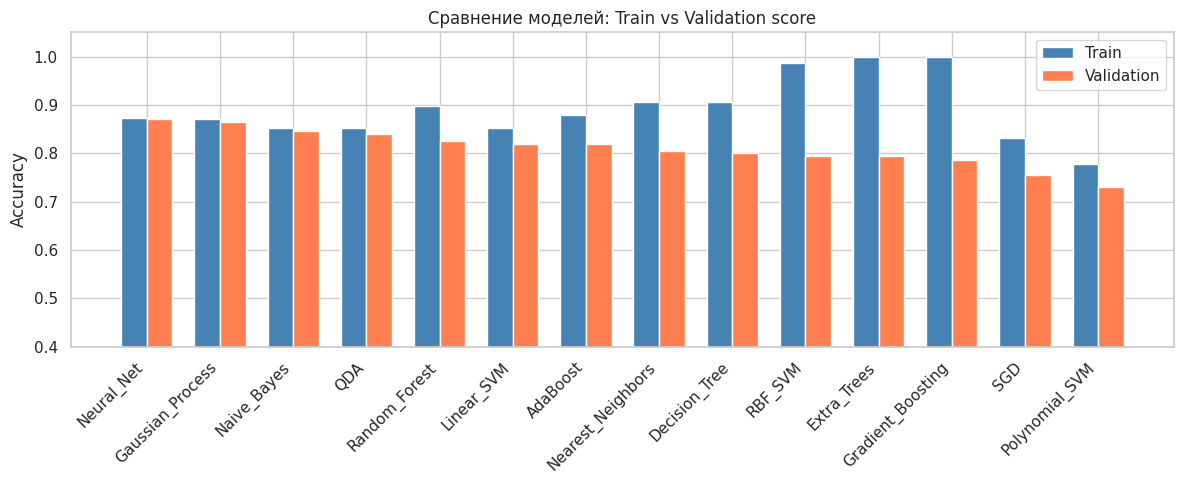

In [21]:
df_plot = df.copy()

x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, df_plot['train_score'], width, label='Train', color='steelblue')
ax.bar(x + width/2, df_plot['val_score'],   width, label='Validation', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Train vs Validation score')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['name'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

In [30]:
import time
import warnings
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
    'alpha':              [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.05],
    'activation':         ['relu', 'tanh']
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)

grid_cv = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_cv.fit(X_train, Y_train)

print(f"Лучшие параметры: {grid_cv.best_params_}")
print(f"Лучший CV score:  {grid_cv.best_score_:.4f}")
print(f"Val  score:       {grid_cv.best_estimator_.score(X_val, Y_val):.4f}")
print(f"Test score:       {grid_cv.best_estimator_.score(X_test, Y_test):.4f}")

Лучшие параметры: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}
Лучший CV score:  0.8667
Val  score:       0.8600
Test score:       0.8750


In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
param_distributions = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (200,),
                           (50, 50), (100, 50), (100, 100), (150, 100),
                           (100, 50, 25)],
    'alpha':              loguniform(1e-5, 1),
    'learning_rate_init': loguniform(1e-4, 0.1),
    'activation':         ['relu', 'tanh', 'logistic']
}

n_iter = 40

random_cv = RandomizedSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    param_distributions,
    n_iter=n_iter,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_cv.fit(X_train, Y_train)
print(f"Лучшие параметры: {random_cv.best_params_}")
print(f"Лучший CV score:  {random_cv.best_score_:.4f}")
print(f"Val  score:       {random_cv.best_estimator_.score(X_val, Y_val):.4f}")
print(f"Test score:       {random_cv.best_estimator_.score(X_test, Y_test):.4f}")

Лучшие параметры: {'activation': 'relu', 'alpha': np.float64(0.7072114131472232), 'hidden_layer_sizes': (100, 50), 'learning_rate_init': np.float64(0.0001005394019469303)}
Лучший CV score:  0.8667
Val  score:       0.8650
Test score:       0.8750


In [45]:
pd.set_option('display.max_colwidth', None)

comparison = pd.DataFrame({
    'Метод': ['Базовая MLPClassifier', 'GridSearchCV', 'RandomizedSearchCV'],
    'Лучшие параметры': [
        'alpha=1, max_iter=1000',
        str(grid_cv.best_params_),
        str(random_cv.best_params_)
    ],
    'CV score': ['-', f"{grid_cv.best_score_:.4f}", f"{random_cv.best_score_:.4f}"],
    'Val score': [
        f"{best_clf.score(X_val, Y_val):.4f}",
        f"{grid_cv.best_estimator_.score(X_val, Y_val):.4f}",
        f"{random_cv.best_estimator_.score(X_val, Y_val):.4f}"
    ],
    'Test score': [
        f"{best_clf.score(X_test, Y_test):.4f}",
        f"{grid_cv.best_estimator_.score(X_test, Y_test):.4f}",
        f"{random_cv.best_estimator_.score(X_test, Y_test):.4f}"
    ],
})

comparison

,Метод,Лучшие параметры,CV score,Val score,Test score
0,Базовая MLPClassifier,"alpha=1, max_iter=1000",-,0.8700,0.8850
1,GridSearchCV,"{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}",0.8667,0.8600,0.8750
2,RandomizedSearchCV,"{'activation': 'relu', 'alpha': np.float64(0.7072114131472232), 'hidden_layer_sizes': (100, 50), 'learning_rate_init': np.float64(0.0001005394019469303)}",0.8667,0.8650,0.8750
